# Kyle Nadeau's Exploratory Analysis

In [4]:
import pathlib
import yaml
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Global Vars
## Project Root Directory
PROJECT_ROOT = pathlib.Path.cwd().parents[1]
config_path = PROJECT_ROOT / "config" / "dev" / "db_config.yaml"


In [6]:
# Load DB Config
with (config_path).open("r") as f:
    cfg = yaml.safe_load(f)

# Build engine
url = (
    f"postgresql+psycopg2://{cfg['user']}:{cfg['password']}@"
    f"{cfg['host']}:{cfg['port']}/{cfg['database']}"
)
engine = create_engine(url)

In [7]:
data = pd.read_sql("SELECT * FROM v_fullTable", con = engine)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

In [8]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
data['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [10]:
data.shape

(7032, 21)

In [11]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
data['SeniorCitizen'].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
data['customerID'].duplicated().sum()

np.int64(0)

## Data quality:

In [15]:
data.isna().mean().sort_values(ascending=False)


customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
OnlineBackup        0.0
gender              0.0
OnlineSecurity      0.0
InternetService     0.0
MultipleLines       0.0
PhoneService        0.0
tenure              0.0
Dependents          0.0
Partner             0.0
SeniorCitizen       0.0
Churn               0.0
dtype: float64

In [16]:
data["Churn"].value_counts(normalize=True).rename("proportion")


Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

In [35]:
data['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

## Churn rate by category:

In [18]:
cat_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]
cat_cols = [c for c in cat_cols if c in data.columns]


def churn_rate_by(df, col, churn_col="Churn"):
    return (
        df.groupby(col, dropna=False)[churn_col]
        .apply(lambda s: (s == "Yes").mean())
        .rename("churn_rate")
        .sort_values(ascending=False)
    )


for col in cat_cols:
    print("\n", col)
    display(churn_rate_by(data, col))



 gender


gender
Female    0.269595
Male      0.262046
Name: churn_rate, dtype: float64


 SeniorCitizen


SeniorCitizen
1    0.416813
0    0.236503
Name: churn_rate, dtype: float64


 Partner


...

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: churn_rate, dtype: float64


 PaperlessBilling


PaperlessBilling
Yes    0.335893
No     0.163757
Name: churn_rate, dtype: float64


 PaymentMethod


PaymentMethod
Electronic check             0.452854
Mailed check                 0.192020
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Name: churn_rate, dtype: float64

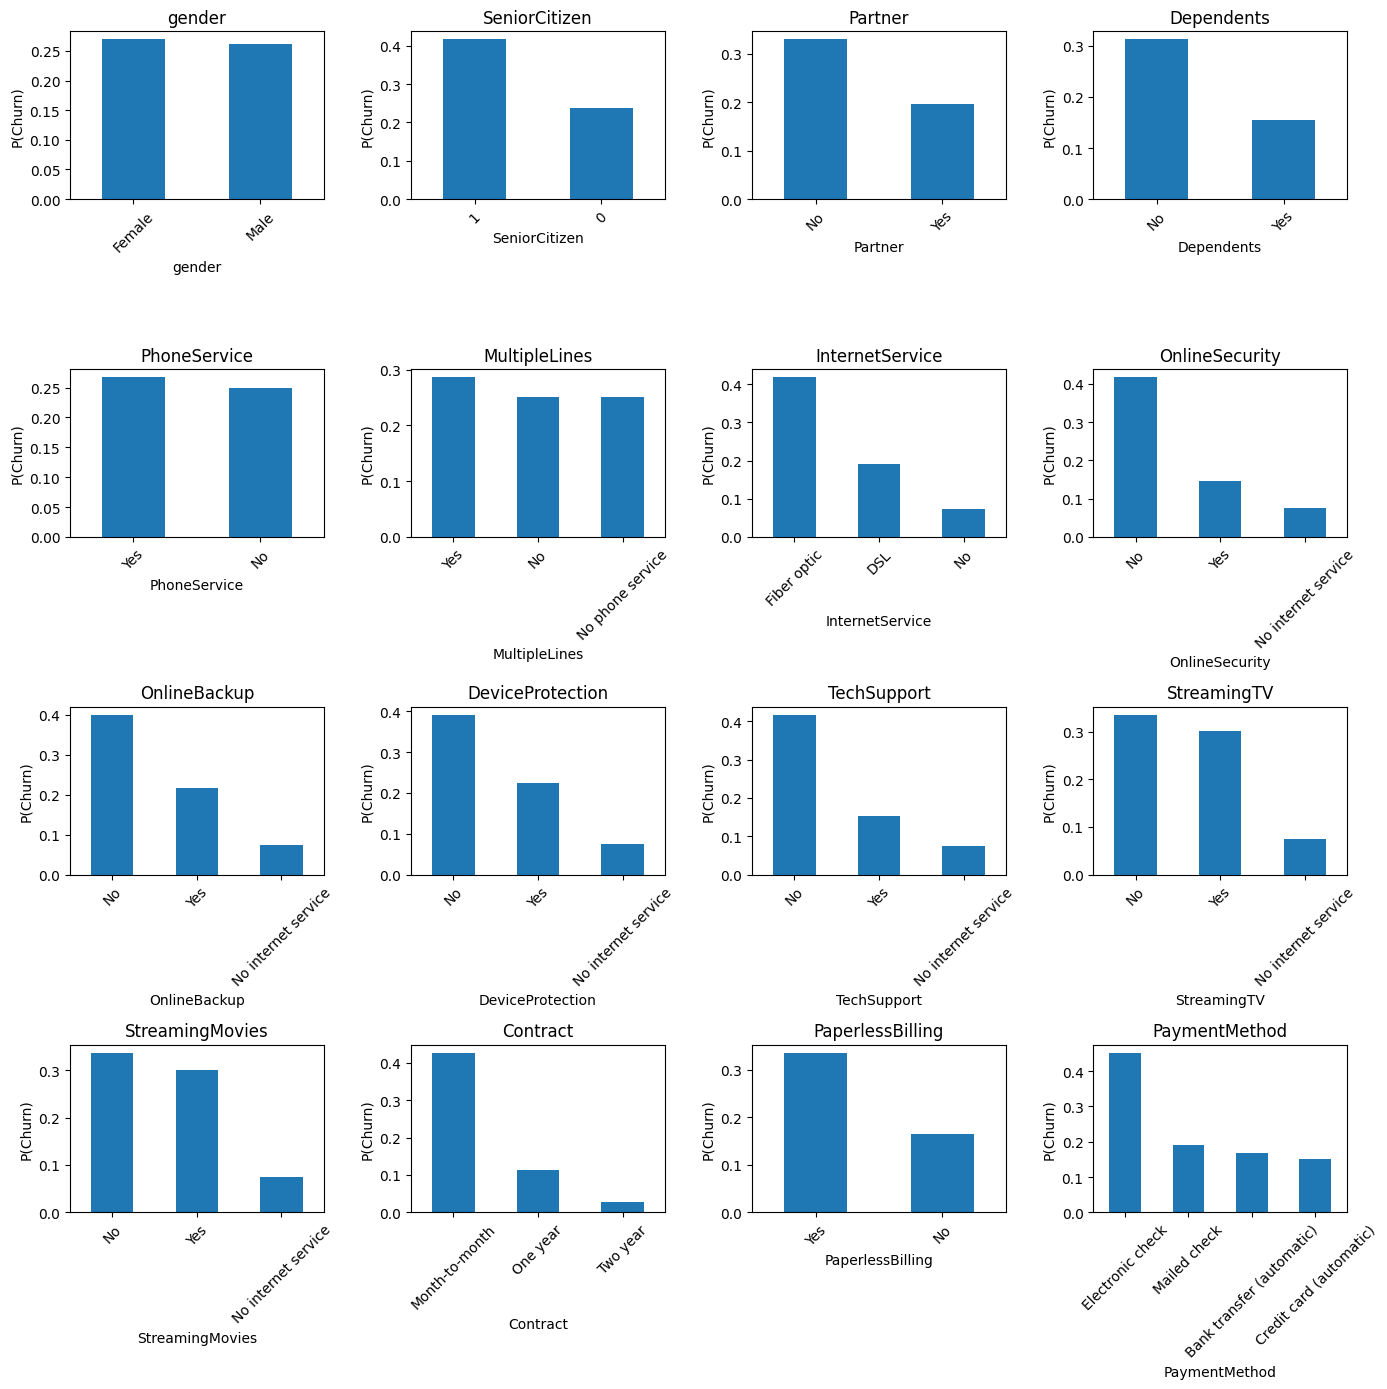

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
    churn_rate_by(data, col).plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("P(Churn)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Numeric distributions and vs Churn:

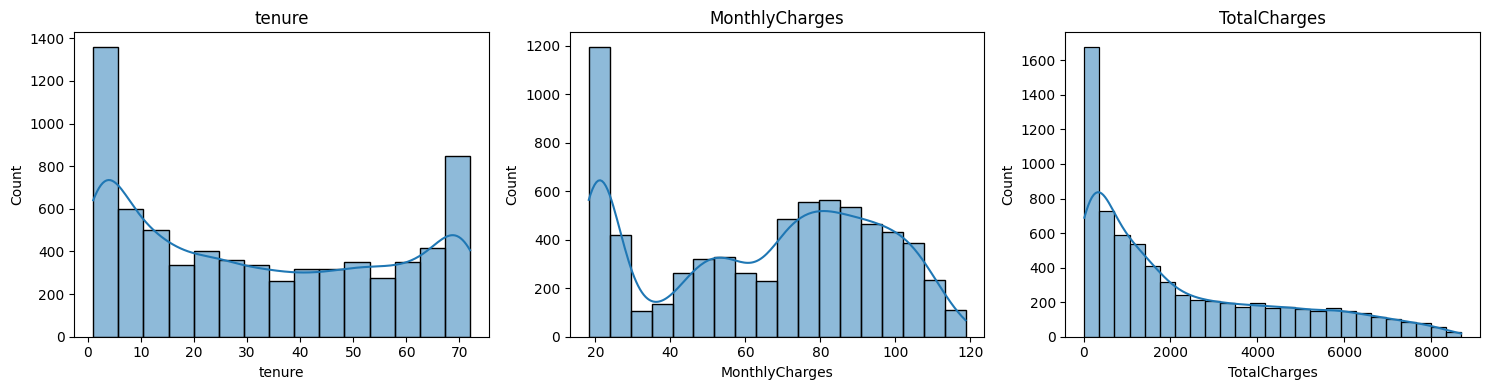

In [30]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
num_cols = [c for c in num_cols if c in data.columns]

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    sns.histplot(data=data, x=col, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


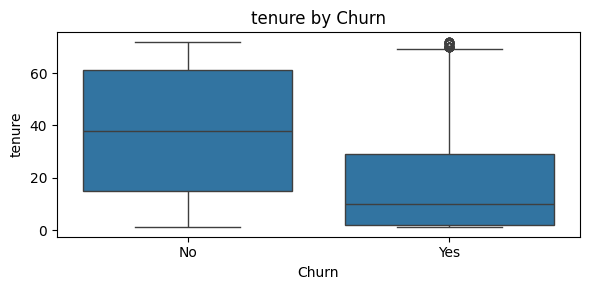

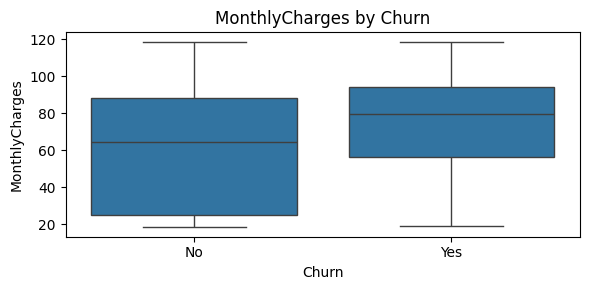

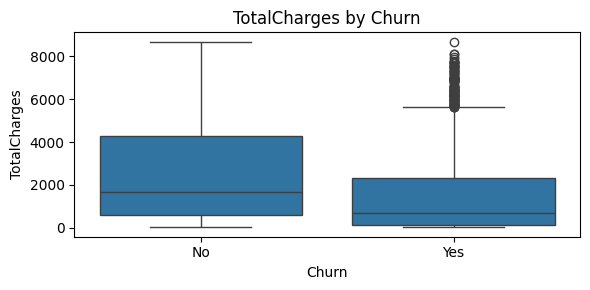

In [21]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=data, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.tight_layout()
    plt.show()


## Correlation (numeric + churn):

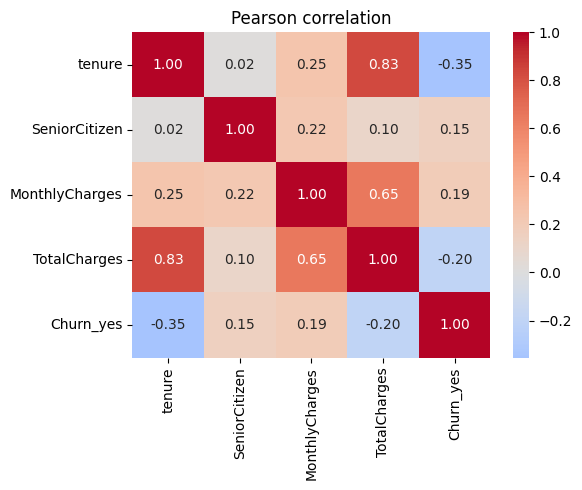

In [22]:
num_for_corr = data[["tenure", "SeniorCitizen", "MonthlyCharges", "TotalCharges"]].copy()
num_for_corr["Churn_yes"] = (data["Churn"] == "Yes").astype(int)
corr = num_for_corr.corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson correlation")
plt.tight_layout()
plt.show()


## Chi-square: categorical vs Churn:

In [23]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    tab = pd.crosstab(data[col], data["Churn"])
    chi2, p, dof, expected = chi2_contingency(tab)
    print(f"{col}: chi2={chi2:.2f}, p={p:.2e}")


gender: chi2=0.48, p=4.90e-01
SeniorCitizen: chi2=158.44, p=2.48e-36
Partner: chi2=157.50, p=3.97e-36
Dependents: chi2=186.32, p=2.02e-42
PhoneService: chi2=0.87, p=3.50e-01
MultipleLines: chi2=11.27, p=3.57e-03
InternetService: chi2=728.70, p=5.83e-159
OnlineSecurity: chi2=846.68, p=1.40e-184
OnlineBackup: chi2=599.18, p=7.78e-131
DeviceProtection: chi2=555.88, p=1.96e-121
TechSupport: chi2=824.93, p=7.41e-180
StreamingTV: chi2=372.46, p=1.32e-81
StreamingMovies: chi2=374.27, p=5.35e-82
Contract: chi2=1179.55, p=7.33e-257
PaperlessBilling: chi2=256.87, p=8.24e-58
PaymentMethod: chi2=645.43, p=1.43e-139


## Tenure bins vs churn:

tenure_bin
(0, 12]     0.476782
(12, 24]    0.287109
(24, 48]    0.203890
(48, 72]    0.095132
Name: churn_rate, dtype: float64

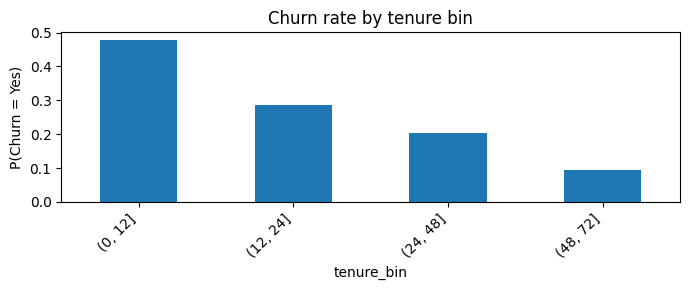

In [24]:
data["tenure_bin"] = pd.cut(
    data["tenure"], bins=[0, 12, 24, 48, 72, 100], right=True
)
display(churn_rate_by(data, "tenure_bin"))
plt.figure(figsize=(7, 3))
churn_rate_by(data, "tenure_bin").plot(kind="bar")
plt.ylabel("P(Churn = Yes)")
plt.title("Churn rate by tenure bin")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Two-way interaction: Contract × InternetService


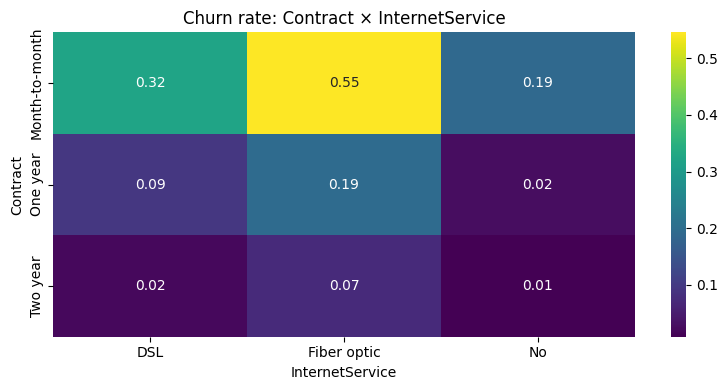

In [25]:
g = (
    data.groupby(["Contract", "InternetService"], dropna=False)["Churn"]
    .apply(lambda s: (s == "Yes").mean())
    .reset_index(name="churn_rate")
)
pivot = g.pivot(index="Contract", columns="InternetService", values="churn_rate")
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title("Churn rate: Contract × InternetService")
plt.tight_layout()
plt.show()


## Outliers (IQR) on charges:


In [26]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


for col in ["MonthlyCharges", "TotalCharges"]:
    lo, hi = iqr_bounds(data[col].dropna())
    n_out = ((data[col] < lo) | (data[col] > hi)).sum()
    print(col, "IQR bounds", (round(lo, 2), round(hi, 2)), "n_outliers", int(n_out))


MonthlyCharges IQR bounds (-45.82, 171.27) n_outliers 0
TotalCharges IQR bounds (-4688.48, 8884.67) n_outliers 0


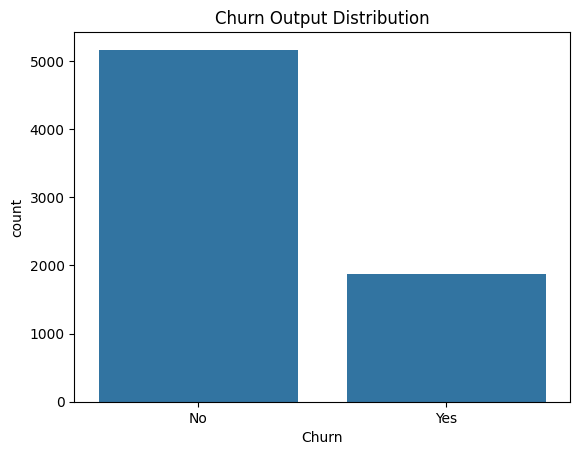

In [28]:
sns.countplot(data = data, x = 'Churn')
plt.title('Churn Output Distribution')
plt.show()